# Statistic of simulated data

TODO: write git version of last functional run!

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [7]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
import platosim.utilities as ut
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [5]:
path = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020"

---
## VSC overview
---

In [ ]:
paramFile = f'{path}/cluster_fcam.data'

<IPython.core.display.Javascript object>


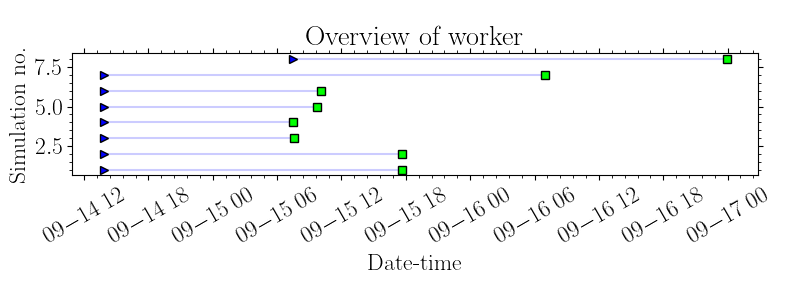

All simulations finished successfully!


In [4]:
workerLog = f'{path}/slurmFCAM_sim3/worker.pbs.log55215928'
paramFileNew = '/lhome/nicholas/cluster.retry'

workerOverview(workerLog, paramFile, ofile=paramFileNew, plot=True)

---
## Simulation statistics
---

In [ ]:
lcs1 = LightCurve(f'{idir}/P1/lightcurve', mode='multi')
lcs5 = LightCurve(f'{idir}/P5/lightcurve_without_maskupdate', mode='multi')

### Table of all simulated LCs

In [172]:
df1 = lcs1.stat_sims()
df1.head()

100%|██████████████████████████████████████████████████| 1000/1000 [00:11<00:00,


,star,group,camera,quarter
0,1,2,3,24
1,1,3,3,24
2,1,1,3,23
3,1,2,2,24
4,1,2,6,24


In [119]:
df5 = lcs5.stat_sims()
df5.head()

100%|██████████████████████████████████████████████████| 999/999 [00:11<00:00, 8


,star,group,camera,quarter
0,1,1,2,23
1,1,1,6,23
2,1,3,2,24
3,1,3,6,24
4,1,2,6,23


Compared to the 19200 LCs per quarter (i.e. 38400 LCs for both quarters) this is:

P1 sample 76.5% complete

P5 sample 77.1% complete

### Missing simulations

In [175]:
paramFile = '/lhome/nicholas/software/workdir/kul20/slurm/data_quarter.txt'
df0 = pd.read_csv(paramFile)
df0

,star,group,camera,quarter
0,1,1,1,23
1,1,1,1,24
2,1,1,2,23
3,1,1,2,24
4,1,1,3,23
...,...,...,...,...
47995,1000,4,4,24
47996,1000,4,5,23
47997,1000,4,5,24
47998,1000,4,6,23


In [191]:
df1_fail = ut.pdMergeRows(df0, df1, identical=False)
df1_fail = df1_fail[df1_fail.star == 1].sort_values(by=['group', 'camera', 'quarter'])
df1_fail

,star,group,camera,quarter
1,1,1,1,24
3,1,1,2,24
5,1,1,3,24
7,1,1,4,24
9,1,1,5,24
11,1,1,6,24
12,1,2,1,23
14,1,2,2,23
16,1,2,3,23
18,1,2,4,23


In [194]:
df1_fail.where(df1_fail.group == 1)

,star,group,camera,quarter
1,1.0,1.0,1.0,24.0
3,1.0,1.0,2.0,24.0
5,1.0,1.0,3.0,24.0
7,1.0,1.0,4.0,24.0
9,1.0,1.0,5.0,24.0
11,1.0,1.0,6.0,24.0
12,NaN,NaN,NaN,NaN
14,NaN,NaN,NaN,NaN
16,NaN,NaN,NaN,NaN
18,NaN,NaN,NaN,NaN


### LCs per star and quarter

In [96]:
lcs1.stat_lcsPerStar(quarters=[23,24], ofile='stat_simsPerStarP1.txt')

100%|██████████████████████████████████████████████████| 1000/1000 [00:08<00:00,


,star,NsimQ23,NsimQ24,NsimAll
0,1,6,11,17
1,2,0,0,0
2,3,11,11,22
3,4,12,6,18
4,5,12,12,24
...,...,...,...,...
995,996,0,6,6
996,997,0,2,2
997,998,6,6,12
998,999,0,6,6


In [97]:
lcs.stat_lcsPerStar(quarters=[23,24], ofile='stat_simsPerStarP5.txt')

100%|██████████████████████████████████████████████████| 999/999 [00:11<00:00, 9


,star,NsimQ23,NsimQ24,NsimAll
0,1,12,6,18
1,2,12,12,24
2,3,12,11,23
3,4,6,12,18
4,5,12,11,23
...,...,...,...,...
994,996,6,6,12
995,997,0,0,0
996,998,6,6,12
997,999,0,6,6


## LCs per N-CAM

In [5]:
from platosim.hpc import HPC 
hpc = HPC(cpus=8)
# hpc.run(script='platonium', project='kul20', paramFile=paramFile)

In [195]:
statFile = '/lhome/nicholas/software/workdir/kul20/statistics.txt'
df = pd.read_csv(statFile)

In [15]:
df = df.rename(columns={'1': 'star', '1.1':'group', '1.2':'camera', '24':'quarter', '1.3':'flag'})

In [17]:
df[df.flag == 0]

,star,group,camera,quarter,flag
0,1,1,3,23,0
2,1,1,1,23,0
4,1,1,4,23,0
6,1,1,2,23,0
7,1,1,5,23,0
...,...,...,...,...,...
47989,1000,4,2,23,0
47991,1000,4,3,23,0
47993,1000,4,4,23,0
47994,1000,4,5,23,0


Statistics for P5 Q23
Ncams	N_exp	N_sim	Diff
00    	0	11	11
06    	100	58	42
11    	0	1	1
12    	200	188	12
15    	0	1	1
18    	100	92	8
19    	0	1	1
24    	600	148	348	
1000 stars ->	7838/19200 = 40.8%

Statistics for P5 Q24
Ncams	N_exp	N_sim
00    	0	17
01    	0	1
06    	100	48
12    	200	186
17    	0	1
18    	100	95
24    	600	152
1000 stars ->	7896/19200 = 41.1%

Statistics for P1 Q23
Ncams	N_exp	N_sim	Diff
00		82		
01		1
02		3
04		4
05		14
06	100	151
07		7
08		3
09		1
10		11
11		45
12	200	254
13		5
14		4
15		3
16		7
17		15
18		87
19		3
20		5
21		5
22		12
23		49
24	600	217
1000 stars ->	13694/19200 = 71.3%

Statistics for P1 Q24
Ncams	N_exp	N_sim	Diff
00		7
01		2
02		2
03		1
04		1
05		12
06	100	139
07		14
08		8
09		3
10		11
11		44
12	200	220
13		7
14		3
15		5
16		15
17		25
18	100	90
19		15
20		7
21		7
22		27
23		70
24	600	253
1000 stars ->	15629/19200 = 81.4%